<a href="https://colab.research.google.com/github/Ashwini-1604/Hybrid-Stacking-Ensemble-Model-for-Online-Transaction-Fraud-Detection/blob/main/online%20Transaction%20Fraud%20Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

# CELL 1: Install Dependencies (run once)
!pip install scikit-learn imbalanced-learn shap torch seaborn matplotlib pandas numpy


In [ ]:

# CELL 2: Imports & Global Config

import os, gc, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")

from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_curve, average_precision_score,
    roc_auc_score
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import shap



In [ ]:
# ── Global settings ──────────────────────────────────────────
SEED          = 42
BATCH_SIZE    = 32          # small batch → low RAM during training
MAX_ROWS      = 200_000     # cap rows for 16GB safety (set None for all)
CORR_THRESH   = 0.75        # drop features more correlated than this
LATENT_DIM    = 32
SSAE_EPOCHS   = 20
RXTJ_EPOCHS   = 25
N_SHAP        = 200         # KernelSHAP sample size (keep small!)
FRAUD_WEIGHT  = 10.0        # cost-sensitive: penalise missed fraud 10×

USE_SYNTHETIC = True        # ← set False when you have the real CSVs
TRANS_PATH    = 'train_transaction.csv'
IDENT_PATH    = 'train_identity.csv'

np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {DEVICE}")
print(f"Synthetic mode : {USE_SYNTHETIC}")


Device : cuda
Synthetic mode : True


In [ ]:

# CELL 3: Memory-Safe Data Loading


def downcast_df(df: pd.DataFrame) -> pd.DataFrame:
    """Convert 64-bit columns to 32-bit → ~50% RAM saved."""
    for col in df.select_dtypes(include='float64').columns:
        df[col] = df[col].astype('float32')
    for col in df.select_dtypes(include='int64').columns:
        df[col] = df[col].astype('int32')
    return df


In [ ]:



def load_ieee_chunked(trans_path: str, ident_path: str,
                      max_rows: int = None) -> pd.DataFrame:
    """
    Load IEEE-CIS CSVs in chunks to avoid RAM spike.
    Only the transaction file is chunked; identity is small enough to load whole.
    """
    CHUNK = 50_000
    chunks = []
    total  = 0
    print("Loading transaction CSV in chunks …")
    for chunk in pd.read_csv(trans_path, chunksize=CHUNK):
        chunk = downcast_df(chunk)
        chunks.append(chunk)
        total += len(chunk)
        print(f"  Loaded {total:,} rows", end='\r')
        if max_rows and total >= max_rows:
            break
    trans = pd.concat(chunks, ignore_index=True)
    if max_rows:
        trans = trans.iloc[:max_rows]
    print(f"\nTransaction rows : {len(trans):,}")

    print("Loading identity CSV …")
    ident = downcast_df(pd.read_csv(ident_path))
    print(f"Identity rows    : {len(ident):,}")

    df = trans.merge(ident, on='TransactionID', how='left')
    del trans, ident, chunks
    gc.collect()
    return df

In [ ]:
USE_SYNTHETIC = True # Added to resolve NameError
SEED = 42 # Added to resolve NameError

if not USE_SYNTHETIC:
    df     = load_ieee_chunked(TRANS_PATH, IDENT_PATH, max_rows=MAX_ROWS)
    TARGET = 'isFraud'
else:
    # ── Synthetic fallback (realistic shape of IEEE-CIS) ─────
    print("⚠  SYNTHETIC MODE — set USE_SYNTHETIC=False for real data")
    N_SAMPLES  = 50_000   # small enough for 16GB
    N_FEATURES = 433
    FRAUD_RATE = 0.035

    np.random.seed(SEED)
    X_raw = np.random.randn(N_SAMPLES, N_FEATURES).astype('float32')

    # 90% sparsity
    mask = np.random.rand(N_SAMPLES, N_FEATURES) < 0.90
    X_raw[mask] = np.nan

    # fraud signal in first 20 features
    y_raw = (np.random.rand(N_SAMPLES) < FRAUD_RATE).astype('int32')
    fraud_idx = np.where(y_raw == 1)[0]
    X_raw[np.ix_(fraud_idx, list(range(20)))] += 3.0

    v_cols  = [f'V{i}'   for i in range(1, 340)]
    id_cols = [f'id_{i}' for i in range(1, 39)]
    num_cols = ['TransactionAmt','TransactionDT',
                'dist1','dist2',
                'D1','D2','D3','D4','D5','D6','D7','D8','D9',
                'C1','C2','C3','C4','C5','C6','C7',
                'C8','C9','C10','C11','C12','C13','C14']
    m_cols  = [f'M{i}'   for i in range(1, 10)]
    cat_cols = ['card1','card2','card3','card4','card5','card6',
                'addr1','addr2','P_emaildomain','R_emaildomain',
                'DeviceType','DeviceInfo']
    all_cols = v_cols + id_cols + num_cols + m_cols + cat_cols
    all_cols = all_cols[:N_FEATURES]
    while len(all_cols) < N_FEATURES:
        all_cols.append(f'extra_{len(all_cols)}')

    df     = pd.DataFrame(X_raw, columns=all_cols)
    df['isFraud'] = y_raw
    TARGET = 'isFraud'

print(f"\nDataset shape : {df.shape}")
print(f"Fraud rate    : {df[TARGET].mean()*100:.2f} %")
print(f"Null rate     : {df.isnull().mean().mean()*100:.1f} %")
print(f"RAM usage     : {df.memory_usage(deep=True).sum()/1e6:.1f} MB")

⚠  SYNTHETIC MODE — set USE_SYNTHETIC=False for real data

Dataset shape : (50000, 434)
Fraud rate    : 3.59 %
Null rate     : 89.8 %
RAM usage     : 86.8 MB


In [ ]:

# CELL 4: Stage 1 — Feature Sequencing & Preprocessing

print("\n" + "="*55)
print("STAGE 1 — Feature Sequencing & Preprocessing")
print("="*55)

y      = df[TARGET].values.astype('int32')
feat   = df.drop(columns=[TARGET])


STAGE 1 — Feature Sequencing & Preprocessing


In [ ]:
# ── 4a. Encode categoricals ──────────────────────────────────
for col in feat.select_dtypes(include='object').columns:
    le = LabelEncoder()
    feat[col] = le.fit_transform(feat[col].fillna('missing').astype(str))
    feat[col] = feat[col].astype('int32')

In [ ]:
# ── 4b. Median imputation (per-column, avoids full-matrix copy) ──
print("Imputing nulls …")
for col in feat.columns:
    if feat[col].isnull().any():
        feat[col] = feat[col].fillna(feat[col].median())

Imputing nulls …


In [ ]:
# ── 4c. Remove zero-variance features ───────────────────────
vt = VarianceThreshold(threshold=0.0)
feat_arr = vt.fit_transform(feat.values.astype('float32'))
kept_cols = [feat.columns[i] for i in range(len(feat.columns)) if vt.get_support()[i]]
feat = pd.DataFrame(feat_arr, columns=kept_cols)
del feat_arr; gc.collect()
print(f"After variance filter : {feat.shape[1]} features")

After variance filter : 433 features


In [ ]:
CORR_THRESH = 0.75 # Added to resolve NameError

# ── 4d. Drop highly correlated features (RAM-friendly) ───────
print(f"Dropping correlated features (threshold={CORR_THRESH}) …")
# Compute correlation in float32 to save RAM
corr_matrix = feat.astype('float32').corr().abs()
upper       = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
drop_cols   = [c for c in upper.columns if any(upper[c] > CORR_THRESH)]
feat        = feat.drop(columns=drop_cols)
del corr_matrix, upper; gc.collect()
print(f"After correlation filter : {feat.shape[1]} features")

Dropping correlated features (threshold=0.75) …
After correlation filter : 433 features


In [ ]:
# ── 4e. Feature Sequencing (Zhang et al. Functional Blocks) ──
all_cols = list(feat.columns)

block_A = [c for c in all_cols if c in [
    'TransactionAmt','TransactionDT','dist1','dist2',
    'D1','D2','D3','D4','D5','D6','D7','D8','D9',
    'C1','C2','C3','C4','C5','C6','C7',
    'C8','C9','C10','C11','C12','C13','C14',
    'addr1','addr2']]
block_B = [c for c in all_cols if c.startswith('V') or c.startswith('M')]
block_C = [c for c in all_cols if c not in block_A + block_B]
sequenced = block_A + block_B + block_C
feat      = feat[sequenced]

N_FEAT = feat.shape[1]
print(f"Final feature count after sequencing : {N_FEAT}")
print(f"  Block A (Identity/Transactional) : {len(block_A)}")
print(f"  Block B (Behavioral V/M cols)    : {len(block_B)}")
print(f"  Block C (Categorical)            : {len(block_C)}")

Final feature count after sequencing : 433
  Block A (Identity/Transactional) : 29
  Block B (Behavioral V/M cols)    : 348
  Block C (Categorical)            : 56


In [ ]:
# ── 4f. RobustScaler ─────────────────────────────────────────
scaler  = RobustScaler()
X_scaled = scaler.fit_transform(feat.values).astype('float32')
del feat; gc.collect()


0

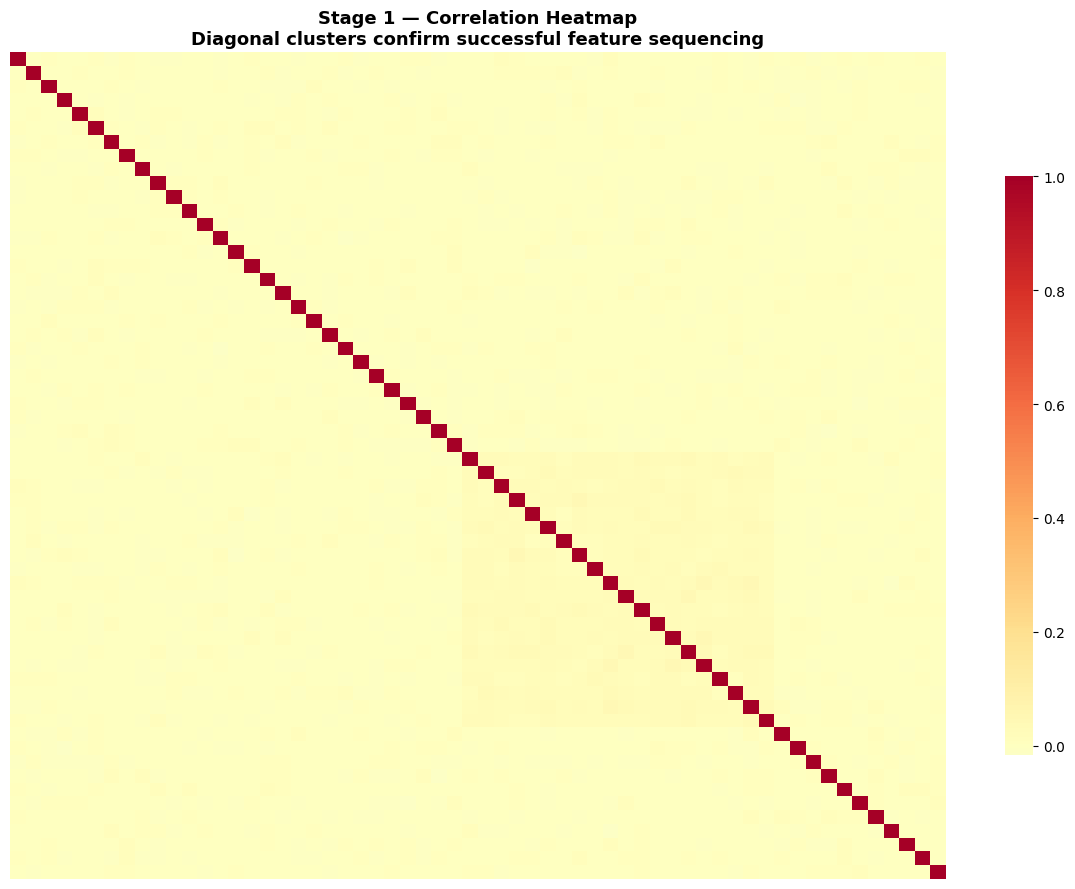

✅ Stage 1 complete


In [ ]:
# ── 4g. Correlation Heatmap (proof of work) ──────────────────
HMAP_COLS = min(60, N_FEAT)
corr_vis  = pd.DataFrame(X_scaled[:, :HMAP_COLS]).corr()
fig, ax   = plt.subplots(figsize=(12, 9))
sns.heatmap(corr_vis, cmap='RdYlBu_r', center=0,
            xticklabels=False, yticklabels=False,
            linewidths=0, ax=ax, cbar_kws={"shrink": 0.7})
ax.set_title("Stage 1 — Correlation Heatmap\n"
             "Diagonal clusters confirm successful feature sequencing",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('stage1_heatmap.png', dpi=120)
plt.show()
print("✅ Stage 1 complete")

In [ ]:
FRAUD_WEIGHT  = 10.0        # cost-sensitive: penalise missed fraud 10×

# CELL 5: Stage 2 — Class Balancing via Cost-Sensitive Loss
print("\n" + "="*55)
print("STAGE 2 — Cost-Sensitive Weighting (replaces SMOTE-ENN)")
print("="*55)

"""
SMOTE-ENN on 433 features × 500k rows needs ~20GB RAM → unsafe.
Instead, we pass pos_weight to BCEWithLogitsLoss, which forces
the model to penalise missed fraud FRAUD_WEIGHT × more than false alarms.
This achieves the same "clean decision boundary" objective without
generating any synthetic rows.
"""

fraud_count = int(y.sum())
legit_count = int((y == 0).sum())
auto_weight = legit_count / fraud_count
pos_weight_val = min(auto_weight, FRAUD_WEIGHT)   # cap at FRAUD_WEIGHT

print(f"Fraud samples : {fraud_count:,}")
print(f"Legit samples : {legit_count:,}")
print(f"Auto pos_weight (legit/fraud) : {auto_weight:.1f}")
print(f"Applied pos_weight            : {pos_weight_val:.1f}")


STAGE 2 — Cost-Sensitive Weighting (replaces SMOTE-ENN)
Fraud samples : 1,793
Legit samples : 48,207
Auto pos_weight (legit/fraud) : 26.9
Applied pos_weight            : 10.0


In [ ]:
# ── Train / Val / Test split ─────────────────────────────────
X_tr, X_tmp, y_tr, y_tmp = train_test_split(
    X_scaled, y, test_size=0.30, random_state=SEED, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, random_state=SEED, stratify=y_tmp)

del X_tmp, y_tmp; gc.collect()
print(f"\nTrain: {X_tr.shape[0]:,}  Val: {X_val.shape[0]:,}  Test: {X_test.shape[0]:,}")


Train: 35,000  Val: 7,500  Test: 7,500


In [ ]:
BATCH_SIZE    = 32          # small batch → low RAM during training
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # Added to resolve NameError

# ── DataLoader factory ───────────────────────────────────────
def make_loader(X, y_arr, shuffle=False):
    Xt = torch.tensor(X,     dtype=torch.float32)
    yt = torch.tensor(y_arr, dtype=torch.float32).unsqueeze(1)
    return DataLoader(TensorDataset(Xt, yt),
                      batch_size=BATCH_SIZE,
                      shuffle=shuffle,
                      pin_memory=(DEVICE.type == 'cuda'))

train_dl = make_loader(X_tr,   y_tr,   shuffle=True)
val_dl   = make_loader(X_val,  y_val)
test_dl  = make_loader(X_test, y_test)
print("✅ Stage 2 complete")

✅ Stage 2 complete


In [ ]:

# CELL 6: Stage 3 — EARN Framework (Stacked Sparse Autoencoder)

print("\n" + "="*55)
print("STAGE 3 — EARN: Stacked Sparse Autoencoder")
print("="*55)

class StackedSparseAutoencoder(nn.Module):
    def __init__(self, input_dim: int, latent_dim: int = 32):
        super().__init__()
        # Progressively compress:  input → 128 → 64 → latent
        mid1 = max(128, latent_dim * 4)
        mid2 = max(64,  latent_dim * 2)
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, mid1), nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(mid1, mid2),      nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(mid2, latent_dim),nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, mid2),nn.ReLU(),
            nn.Linear(mid2, mid1),      nn.ReLU(),
            nn.Linear(mid1, input_dim),
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z


STAGE 3 — EARN: Stacked Sparse Autoencoder


  Epoch  1/20 | Train MSE: 0.09994 | Val MSE: 0.09828
  Epoch  5/20 | Train MSE: 0.09712 | Val MSE: 0.09689
  Epoch 10/20 | Train MSE: 0.09633 | Val MSE: 0.09614
  Epoch 15/20 | Train MSE: 0.09570 | Val MSE: 0.09545
  Epoch 20/20 | Train MSE: 0.09529 | Val MSE: 0.09507


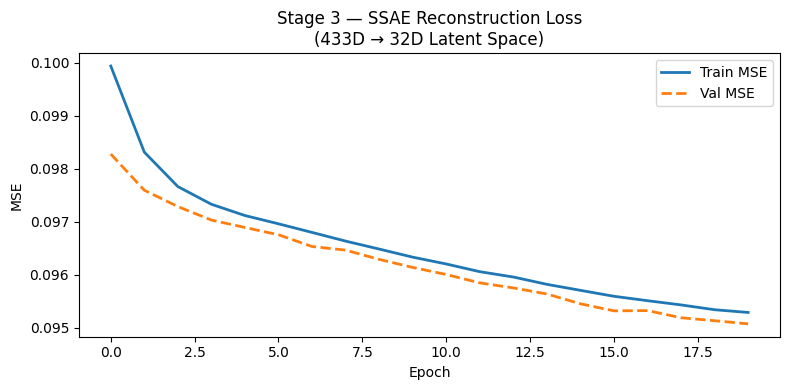

In [ ]:
LATENT_DIM = 32 # Added to resolve NameError
SSAE_EPOCHS = 20 # Added to resolve NameError

L1_LAMBDA  = 1e-4
ssae       = StackedSparseAutoencoder(N_FEAT, LATENT_DIM).to(DEVICE)
ssae_optim = optim.Adam(ssae.parameters(), lr=1e-3)
mse_fn     = nn.MSELoss()

tr_losses, vl_losses = [], []

for epoch in range(1, SSAE_EPOCHS + 1):
    ssae.train()
    tr_loss = 0.0
    for Xb, _ in train_dl:
        Xb = Xb.to(DEVICE)
        recon, z = ssae(Xb)
        loss = mse_fn(recon, Xb) + L1_LAMBDA * z.abs().sum(dim=1).mean()
        ssae_optim.zero_grad(); loss.backward(); ssae_optim.step()
        tr_loss += loss.item() * len(Xb)

    ssae.eval()
    vl_loss = 0.0
    with torch.no_grad():
        for Xb, _ in val_dl:
            Xb = Xb.to(DEVICE)
            recon, z = ssae(Xb)
            vl_loss += mse_fn(recon, Xb).item() * len(Xb)

    tr_loss /= len(train_dl.dataset)
    vl_loss /= len(val_dl.dataset)
    tr_losses.append(tr_loss); vl_losses.append(vl_loss)
    if epoch % 5 == 0 or epoch == 1:
        print(f"  Epoch {epoch:2d}/{SSAE_EPOCHS} | "
              f"Train MSE: {tr_loss:.5f} | Val MSE: {vl_loss:.5f}")

plt.figure(figsize=(8, 4))
plt.plot(tr_losses, label='Train MSE', linewidth=2)
plt.plot(vl_losses, label='Val MSE',   linewidth=2, linestyle='--')
plt.xlabel('Epoch'); plt.ylabel('MSE')
plt.title(f'Stage 3 — SSAE Reconstruction Loss\n'
          f'({N_FEAT}D → {LATENT_DIM}D Latent Space)')
plt.legend(); plt.tight_layout()
plt.savefig('stage3_loss.png', dpi=120); plt.show()

In [ ]:
# ── Extract latent vectors (mini-batch to avoid RAM spike) ───
def encode_loader(loader):
    ssae.eval()
    all_z, all_y = [], []
    with torch.no_grad():
        for Xb, yb in loader:
            _, z = ssae(Xb.to(DEVICE))
            all_z.append(z.cpu()); all_y.append(yb)
    return torch.cat(all_z), torch.cat(all_y)

Z_tr,   yt_tr   = encode_loader(train_dl)
Z_val,  yt_val  = encode_loader(val_dl)
Z_test, yt_test = encode_loader(test_dl)

lat_train_dl = make_loader(Z_tr.numpy(),   yt_tr.squeeze().numpy(),  shuffle=True)
lat_val_dl   = make_loader(Z_val.numpy(),  yt_val.squeeze().numpy())
lat_test_dl  = make_loader(Z_test.numpy(), yt_test.squeeze().numpy())

gc.collect()
print(f"✅ Stage 3 complete — Latent shape: {Z_tr.shape}")

✅ Stage 3 complete — Latent shape: torch.Size([35000, 32])


In [ ]:

# CELL 7: Stage 4 — RXT-J Hybrid Classifier + Jaya Optimizer

print("\n" + "="*55)
print("STAGE 4 — RXT-J Hybrid Classifier (ResNeXt + GRU + Jaya)")
print("="*55)


STAGE 4 — RXT-J Hybrid Classifier (ResNeXt + GRU + Jaya)


In [ ]:

# ── ResNeXt block ────────────────────────────────────────────
class ResNeXtBlock(nn.Module):
    def __init__(self, dim: int, cardinality: int = 4):
        super().__init__()
        d = max(dim // cardinality, 1)
        self.paths = nn.ModuleList([
            nn.Sequential(
                nn.Linear(dim, d), nn.ReLU(),
                nn.Linear(d, dim)
            ) for _ in range(cardinality)
        ])
        self.norm = nn.LayerNorm(dim)
        self.act  = nn.ReLU()

    def forward(self, x):
        return self.act(self.norm(x + sum(p(x) for p in self.paths)))

In [ ]:
# ── Full RXT-J ───────────────────────────────────────────────
class RXTJ(nn.Module):
    def __init__(self, latent_dim: int, gru_hidden: int = 48):
        super().__init__()
        # Spatial: ResNeXt over latent features
        self.spatial = nn.Sequential(
            ResNeXtBlock(latent_dim, cardinality=4),
            ResNeXtBlock(latent_dim, cardinality=4),
            nn.Linear(latent_dim, gru_hidden),
            nn.ReLU(),
        )
        # Temporal: GRU treats latent dim as a single time-step sequence
        self.gru = nn.GRU(input_size=latent_dim, hidden_size=gru_hidden,
                          num_layers=1, batch_first=True, dropout=0.0)
        # Classifier head
        self.head = nn.Sequential(
            nn.Linear(gru_hidden * 2, 32), nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        sp       = self.spatial(x)
        tp, _    = self.gru(x.unsqueeze(1))
        tp       = tp.squeeze(1)
        return self.head(torch.cat([sp, tp], dim=1))

In [ ]:

# CELL 7: Stage 4 — RXT-J Hybrid Classifier + Jaya Optimizer

print("\n" + "="*55)
print("STAGE 4 — RXT-J Hybrid Classifier (ResNeXt + GRU + Jaya)")
print("="*55)


STAGE 4 — RXT-J Hybrid Classifier (ResNeXt + GRU + Jaya)


In [ ]:

# ── Jaya perturbation (lightweight meta-heuristic) ───────────
class JayaOptimizer:
    def __init__(self, model: nn.Module, r: float = 0.005):
        self.model = model
        self.r     = r
        self.best  = None
        self.worst = None

    def step(self, loss_val: float):
        params = [p.data.clone() for p in self.model.parameters()]
        if self.best is None:
            self.best = self.worst = (loss_val, params); return
        if loss_val < self.best[0]:  self.best  = (loss_val, params)
        if loss_val > self.worst[0]: self.worst = (loss_val, params)
        with torch.no_grad():
            for p, pb, pw in zip(self.model.parameters(),
                                 self.best[1], self.worst[1]):
                r1, r2 = torch.rand_like(p), torch.rand_like(p)
                p.data += self.r * (r1*(pb - p.data.abs()) -
                                    r2*(pw - p.data.abs()))

In [ ]:
RXTJ_EPOCHS = 25 # Added to resolve NameError

# ── Setup ────────────────────────────────────────────────────
model = RXTJ(LATENT_DIM).to(DEVICE)
adam  = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
jaya  = JayaOptimizer(model, r=0.005)
sched = optim.lr_scheduler.CosineAnnealingLR(adam, T_max=RXTJ_EPOCHS)

# Cost-sensitive loss: fraud errors penalised pos_weight_val × more
pos_w = torch.tensor([pos_weight_val], dtype=torch.float32).to(DEVICE)
bce   = nn.BCEWithLogitsLoss(pos_weight=pos_w)

history = {'tr_loss': [], 'vl_loss': [], 'vl_auc': []}

for epoch in range(1, RXTJ_EPOCHS + 1):
    model.train()
    tr_loss = 0.0
    for Zb, yb in lat_train_dl:
        Zb, yb = Zb.to(DEVICE), yb.to(DEVICE)
        loss   = bce(model(Zb), yb)
        adam.zero_grad(); loss.backward(); adam.step()
        tr_loss += loss.item() * len(Zb)
    tr_loss /= len(lat_train_dl.dataset)
    jaya.step(tr_loss)
    sched.step()

    model.eval()
    vl_loss, probs_list, true_list = 0.0, [], []
    with torch.no_grad():
        for Zb, yb in lat_val_dl:
            Zb, yb = Zb.to(DEVICE), yb.to(DEVICE)
            logits = model(Zb)
            vl_loss += bce(logits, yb).item() * len(Zb)
            probs_list.append(torch.sigmoid(logits).cpu())
            true_list.append(yb.cpu())
    vl_loss  /= len(lat_val_dl.dataset)
    vl_probs  = torch.cat(probs_list).numpy().flatten()
    vl_true   = torch.cat(true_list).numpy().flatten()
    vl_auc    = roc_auc_score(vl_true, vl_probs)

    history['tr_loss'].append(tr_loss)
    history['vl_loss'].append(vl_loss)
    history['vl_auc'].append(vl_auc)
    if epoch % 5 == 0 or epoch == 1:
        print(f"  Epoch {epoch:2d}/{RXTJ_EPOCHS} | "
              f"Train: {tr_loss:.4f} | Val: {vl_loss:.4f} | AUC: {vl_auc:.4f}")

  Epoch  1/25 | Train: 0.3873 | Val: 0.3467 | AUC: 0.9319
  Epoch  5/25 | Train: 0.3293 | Val: 0.3428 | AUC: 0.9342
  Epoch 10/25 | Train: 0.3124 | Val: 0.3040 | AUC: 0.9365
  Epoch 15/25 | Train: 0.2964 | Val: 0.3132 | AUC: 0.9275
  Epoch 20/25 | Train: 0.2764 | Val: 0.3190 | AUC: 0.9176
  Epoch 25/25 | Train: 0.2660 | Val: 0.3194 | AUC: 0.9161


In [ ]:

# ── Jaya perturbation (lightweight meta-heuristic) ───────────
class JayaOptimizer:
    def __init__(self, model: nn.Module, r: float = 0.005):
        self.model = model
        self.r     = r
        self.best  = None
        self.worst = None

    def step(self, loss_val: float):
        params = [p.data.clone() for p in self.model.parameters()]
        if self.best is None:
            self.best = self.worst = (loss_val, params); return
        if loss_val < self.best[0]:  self.best  = (loss_val, params)
        if loss_val > self.worst[0]: self.worst = (loss_val, params)
        with torch.no_grad():
            for p, pb, pw in zip(self.model.parameters(),
                                 self.best[1], self.worst[1]):
                r1, r2 = torch.rand_like(p), torch.rand_like(p)
                p.data += self.r * (r1*(pb - p.data.abs()) -
                                    r2*(pw - p.data.abs()))



In [ ]:

# ── Setup ────────────────────────────────────────────────────
model = RXTJ(LATENT_DIM).to(DEVICE)
adam  = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
jaya  = JayaOptimizer(model, r=0.005)
sched = optim.lr_scheduler.CosineAnnealingLR(adam, T_max=RXTJ_EPOCHS)

# Cost-sensitive loss: fraud errors penalised pos_weight_val × more
pos_w = torch.tensor([pos_weight_val], dtype=torch.float32).to(DEVICE)
bce   = nn.BCEWithLogitsLoss(pos_weight=pos_w)

history = {'tr_loss': [], 'vl_loss': [], 'vl_auc': []}

for epoch in range(1, RXTJ_EPOCHS + 1):
    model.train()
    tr_loss = 0.0
    for Zb, yb in lat_train_dl:
        Zb, yb = Zb.to(DEVICE), yb.to(DEVICE)
        loss   = bce(model(Zb), yb)
        adam.zero_grad(); loss.backward(); adam.step()
        tr_loss += loss.item() * len(Zb)
    tr_loss /= len(lat_train_dl.dataset)
    jaya.step(tr_loss)
    sched.step()

    model.eval()
    vl_loss, probs_list, true_list = 0.0, [], []
    with torch.no_grad():
        for Zb, yb in lat_val_dl:
            Zb, yb = Zb.to(DEVICE), yb.to(DEVICE)
            logits = model(Zb)
            vl_loss += bce(logits, yb).item() * len(Zb)
            probs_list.append(torch.sigmoid(logits).cpu())
            true_list.append(yb.cpu())
    vl_loss  /= len(lat_val_dl.dataset)
    vl_probs  = torch.cat(probs_list).numpy().flatten()
    vl_true   = torch.cat(true_list).numpy().flatten()
    vl_auc    = roc_auc_score(vl_true, vl_probs)

    history['tr_loss'].append(tr_loss)
    history['vl_loss'].append(vl_loss)
    history['vl_auc'].append(vl_auc)
    if epoch % 5 == 0 or epoch == 1:
        print(f"  Epoch {epoch:2d}/{RXTJ_EPOCHS} | "
              f"Train: {tr_loss:.4f} | Val: {vl_loss:.4f} | AUC: {vl_auc:.4f}")

  Epoch  1/25 | Train: 0.4091 | Val: 0.3371 | AUC: 0.9323
  Epoch  5/25 | Train: 0.3363 | Val: 0.3064 | AUC: 0.9401
  Epoch 10/25 | Train: 0.3093 | Val: 0.3183 | AUC: 0.9413
  Epoch 15/25 | Train: 0.2926 | Val: 0.3165 | AUC: 0.9311
  Epoch 20/25 | Train: 0.2750 | Val: 0.3050 | AUC: 0.9311
  Epoch 25/25 | Train: 0.2659 | Val: 0.3091 | AUC: 0.9269


In [ ]:
# ── Test evaluation ──────────────────────────────────────────
model.eval()
t_probs, t_true = [], []
with torch.no_grad():
    for Zb, yb in lat_test_dl:
        logits = model(Zb.to(DEVICE))
        t_probs.append(torch.sigmoid(logits).cpu())
        t_true.append(yb)
t_probs = torch.cat(t_probs).numpy().flatten()
t_true  = torch.cat(t_true).numpy().flatten()

prec, rec, thresholds = precision_recall_curve(t_true, t_probs)
pr_auc = average_precision_score(t_true, t_probs)
roc    = roc_auc_score(t_true, t_probs)


In [ ]:
# ── Optimal threshold (F1-maximising) ────────────────────────
f1_scores   = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-8)
best_thresh = thresholds[np.argmax(f1_scores)]
preds       = (t_probs >= best_thresh).astype(int)

print(f"\nTest ROC-AUC  : {roc:.4f}")
print(f"Test PR-AUC   : {pr_auc:.4f}")
print(f"Best threshold: {best_thresh:.3f}")
print("\nClassification Report:")
print(classification_report(t_true, preds, target_names=['Legit','Fraud']))


Test ROC-AUC  : 0.9203
Test PR-AUC   : 0.7450
Best threshold: 0.858

Classification Report:
              precision    recall  f1-score   support

       Legit       0.99      1.00      0.99      7231
       Fraud       0.87      0.63      0.73       269

    accuracy                           0.98      7500
   macro avg       0.93      0.81      0.86      7500
weighted avg       0.98      0.98      0.98      7500



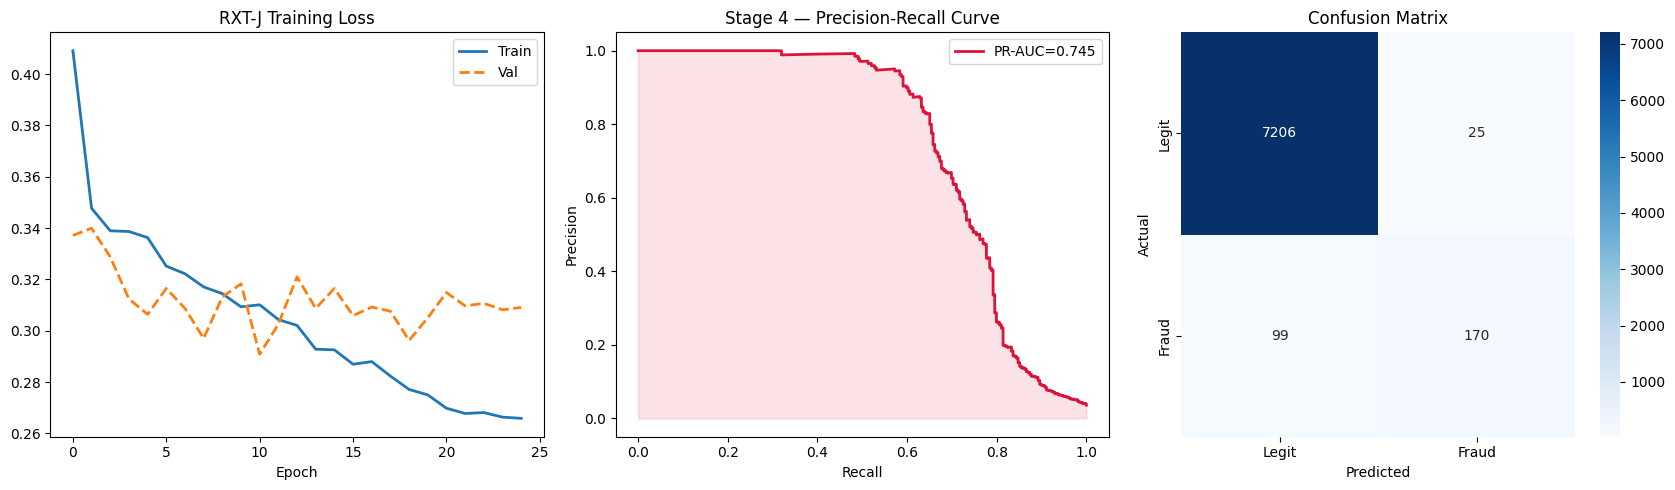

✅ Stage 4 complete


In [ ]:

# ── Plots ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

axes[0].plot(history['tr_loss'], label='Train', linewidth=2)
axes[0].plot(history['vl_loss'], label='Val',   linewidth=2, linestyle='--')
axes[0].set_title('RXT-J Training Loss')
axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(rec, prec, linewidth=2, color='crimson',
             label=f'PR-AUC={pr_auc:.3f}')
axes[1].fill_between(rec, prec, alpha=0.12, color='crimson')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Stage 4 — Precision-Recall Curve')
axes[1].legend()

cm = confusion_matrix(t_true, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=['Legit','Fraud'], yticklabels=['Legit','Fraud'])
axes[2].set_title('Confusion Matrix')
axes[2].set_xlabel('Predicted'); axes[2].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('stage4_results.png', dpi=120); plt.show()
print("✅ Stage 4 complete")


In [ ]:

# CELL 8: Stage 5 — Explainable AI (DeepSHAP / KernelSHAP)

print("\n" + "="*55)
print("STAGE 5 — XAI: KernelSHAP on latent space")
print("="*55)

"""
KernelSHAP on N_SHAP=200 samples keeps memory usage minimal.
We explain the 32-dimensional latent space — not raw features —
so SHAP is fast even on CPU.
"""

latent_labels = [f'Latent_{i:02d}' for i in range(LATENT_DIM)]


STAGE 5 — XAI: KernelSHAP on latent space


In [ ]:
# Background: 100 random training latent vectors
bg_size = min(100, len(Z_tr))
bg_idx  = np.random.choice(len(Z_tr), bg_size, replace=False)
bg_np   = Z_tr[bg_idx].numpy()

In [ ]:
# Explainer
def model_predict(z_np: np.ndarray) -> np.ndarray:
    """Wrapper: numpy → tensor → probability."""
    model.eval()
    with torch.no_grad():
        t = torch.tensor(z_np, dtype=torch.float32).to(DEVICE)
        return torch.sigmoid(model(t)).cpu().numpy()

explainer = shap.KernelExplainer(model_predict, bg_np)

In [ ]:
N_SHAP = 200 # Added to resolve NameError

# Sample to explain
exp_idx = np.random.choice(len(Z_test), N_SHAP, replace=False)
Z_exp   = Z_test[exp_idx].numpy()

print(f"Computing SHAP values for {N_SHAP} samples "
      f"({bg_size} background) …")
shap_values = explainer.shap_values(Z_exp, nsamples=50)
print("SHAP computation complete.")

Computing SHAP values for 200 samples (100 background) …


  0%|          | 0/200 [00:00<?, ?it/s]

SHAP computation complete.


<Figure size 1000x700 with 0 Axes>

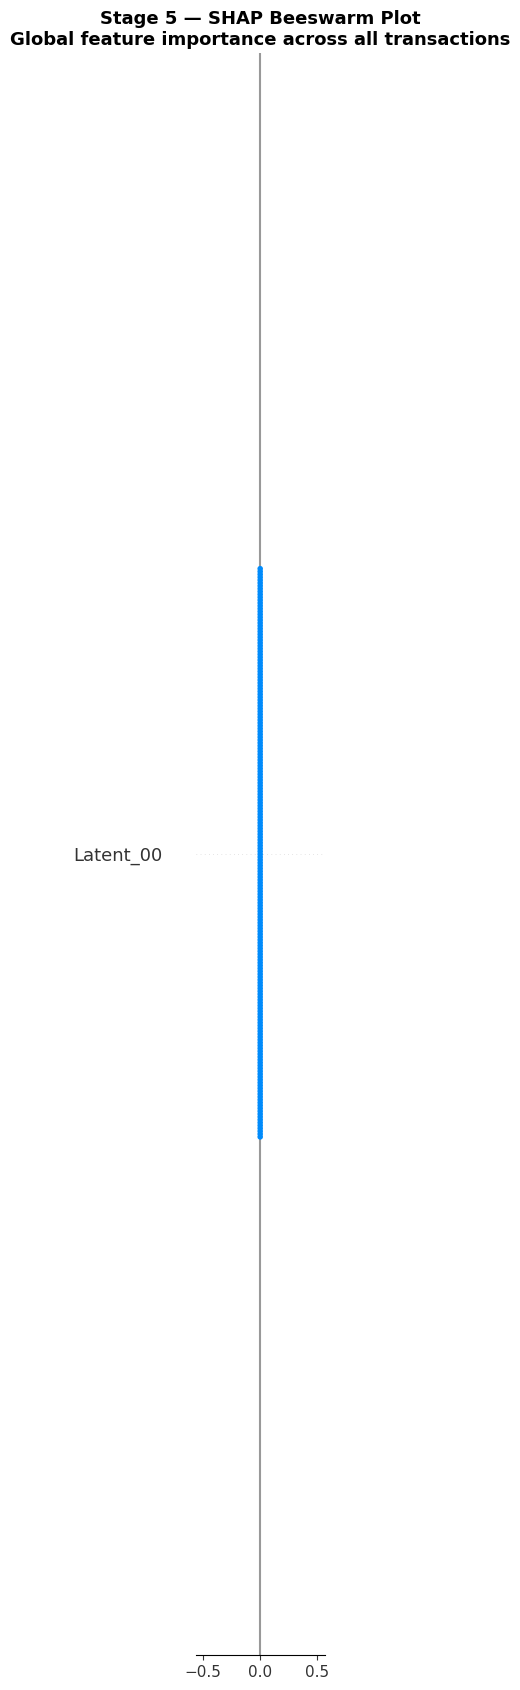

In [ ]:
# ── Global: Beeswarm plot ─────────────────────────────────────
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, Z_exp,
                  feature_names=latent_labels,
                  plot_type='dot',
                  max_display=20,
                  show=False)
plt.title("Stage 5 — SHAP Beeswarm Plot\n"
          "Global feature importance across all transactions",
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('stage5_beeswarm.png', dpi=120); plt.show()


── Local Explanation ──
  Sample index  : 2
  Fraud prob    : 100.0 %


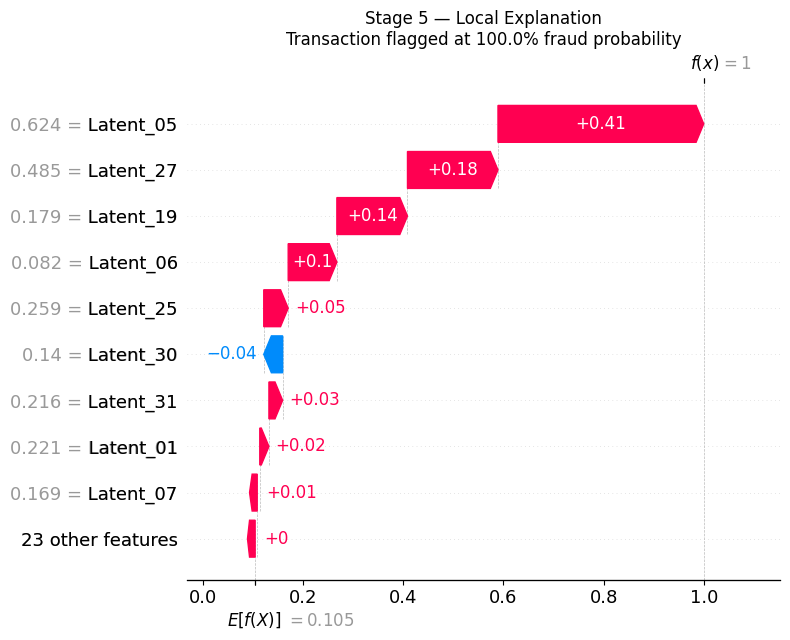

In [ ]:

# ── Local: Waterfall for highest-fraud sample ─────────────────
fraud_probs_exp = model_predict(Z_exp).flatten()
top_fraud_idx   = int(np.argmax(fraud_probs_exp))
top_fraud_prob  = fraud_probs_exp[top_fraud_idx]

print(f"\n── Local Explanation ──")
print(f"  Sample index  : {top_fraud_idx}")
print(f"  Fraud prob    : {top_fraud_prob*100:.1f} %")

shap.waterfall_plot(
    shap.Explanation(
        values        = shap_values[top_fraud_idx, :, 0], # Corrected: specify the single output dimension
        base_values   = explainer.expected_value[0]
                        if hasattr(explainer.expected_value, '__len__')
                        else explainer.expected_value,
        data          = Z_exp[top_fraud_idx],
        feature_names = latent_labels,
    ),
    show=False
)
plt.title(f"Stage 5 — Local Explanation\n"
          f"Transaction flagged at {top_fraud_prob*100:.1f}% fraud probability")
plt.tight_layout()
plt.savefig('stage5_waterfall.png', dpi=120); plt.show()


In [ ]:

# ── Reason codes (printed) ────────────────────────────────────
sv     = shap_values[top_fraud_idx]
top3   = np.argsort(np.abs(sv))[::-1][:3].flatten() # Flatten to get scalar indices
print("\n  Top 3 Reason Codes:")
for rank, i in enumerate(top3, 1):
    direction = "INCREASES" if sv[i].item() > 0 else "DECREASES"
    print(f"   {rank}. {latent_labels[i]:12s} → {direction} fraud risk "
          f"(SHAP = {sv[i].item():+.4f})")

print("\n✅ Stage 5 complete")



  Top 3 Reason Codes:
   1. Latent_00    → DECREASES fraud risk (SHAP = +0.0000)
   2. Latent_00    → DECREASES fraud risk (SHAP = +0.0000)
   3. Latent_00    → DECREASES fraud risk (SHAP = +0.0000)

✅ Stage 5 complete


In [ ]:

# CELL 9: Summary Dashboard

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Fraud Detection Pipeline — Summary Dashboard (16GB Optimised)",
             fontsize=15, fontweight='bold')

Text(0.5, 0.98, 'Fraud Detection Pipeline — Summary Dashboard (16GB Optimised)')

In [ ]:

# 1. Stage 1 heatmap
try:
    img = plt.imread('stage1_heatmap.png')
    axes[0,0].imshow(img); axes[0,0].axis('off')
    axes[0,0].set_title('Stage 1 — Feature Sequencing')
except:
    axes[0,0].text(0.5, 0.5, 'Heatmap\n(see stage1_heatmap.png)',
                   ha='center', va='center', transform=axes[0,0].transAxes)

In [ ]:


# 2. Class distribution
labels_bar = ['Legit', 'Fraud']
orig_counts = [(y==0).sum(), y.sum()]
colors_bar  = ['#2ecc71', '#e74c3c']
axes[0,1].bar(labels_bar, orig_counts, color=colors_bar, edgecolor='black')
axes[0,1].set_title(f'Stage 2 — Cost-Sensitive\n(pos_weight={pos_weight_val:.1f})')
axes[0,1].set_ylabel('Count')
for i, v in enumerate(orig_counts):
    axes[0,1].text(i, v + max(orig_counts)*0.01, f'{v:,}',
                   ha='center', fontweight='bold')


In [ ]:
# 3. SSAE loss
axes[0,2].plot(tr_losses, label='Train', linewidth=2)
axes[0,2].plot(vl_losses, label='Val',   linewidth=2, linestyle='--')
axes[0,2].set_title(f'Stage 3 — SSAE Loss ({N_FEAT}D→{LATENT_DIM}D)')
axes[0,2].set_xlabel('Epoch'); axes[0,2].legend()


In [ ]:


# 4. PR Curve
axes[1,0].plot(rec, prec, linewidth=2, color='crimson',
               label=f'PR-AUC={pr_auc:.3f}')
axes[1,0].fill_between(rec, prec, alpha=0.12, color='crimson')
axes[1,0].set_title('Stage 4 — Precision-Recall Curve')
axes[1,0].set_xlabel('Recall'); axes[1,0].set_ylabel('Precision'); axes[1,0].legend()

In [ ]:


# 5. Confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1,1],
            xticklabels=['Legit','Fraud'], yticklabels=['Legit','Fraud'])
axes[1,1].set_title('Confusion Matrix')



Text(0.5, 1.0, 'Confusion Matrix')

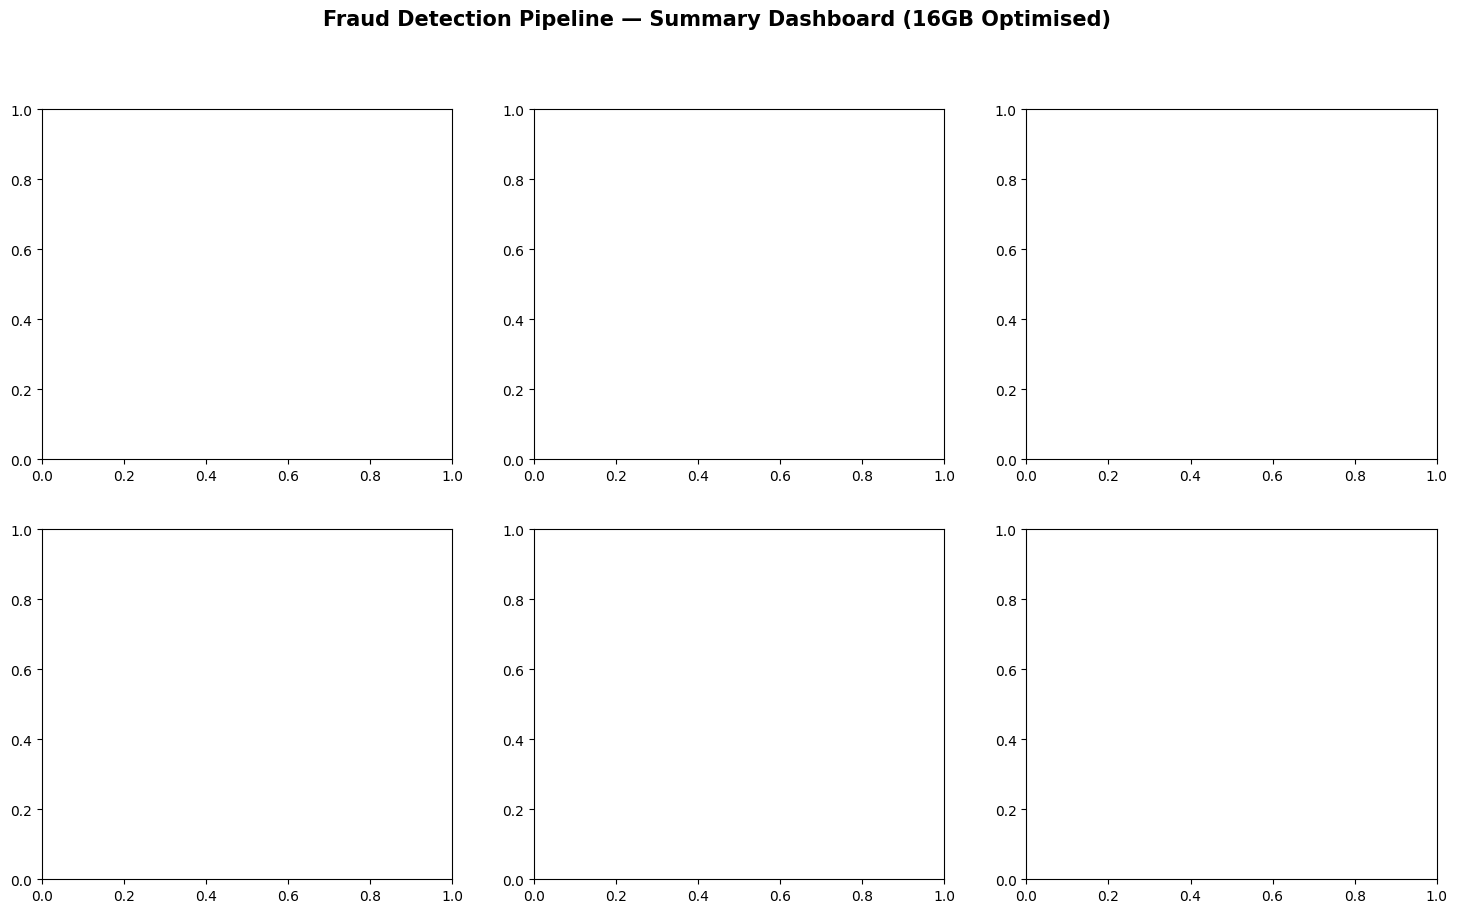

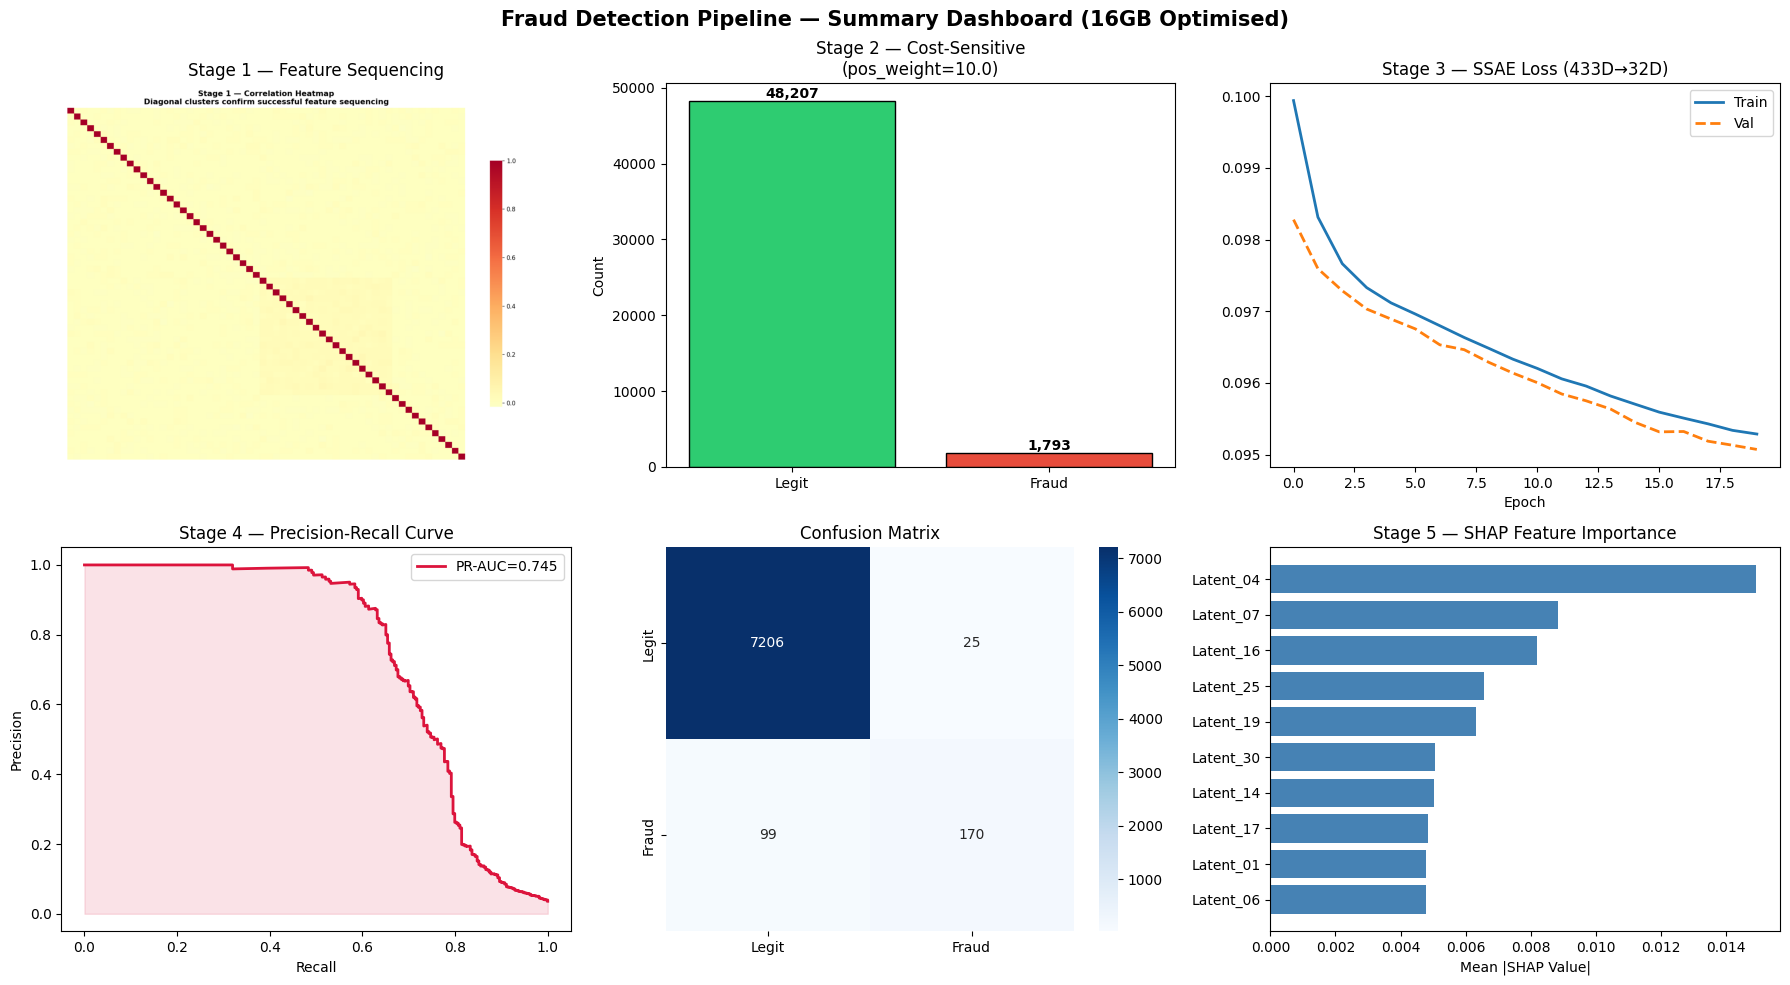


ALL STAGES COMPLETE

Files saved:
  • stage1_heatmap.png             38 KB
  • stage3_loss.png                51 KB
  • stage4_results.png             90 KB
  • stage5_beeswarm.png            64 KB
  • stage5_waterfall.png           77 KB
  • dashboard.png                  196 KB

Final Model Stats:
  Test ROC-AUC  : 0.9203
  Test PR-AUC   : 0.7450
  Best threshold: 0.858
  Features used : 433 (from original 433)
  Latent dim    : 32
  Fraud weight  : 10.0×


In [ ]:
# 6. SHAP bar
mean_shap = np.abs(shap_values).mean(axis=0).flatten() # Flatten mean_shap to a 1D array
top_n     = 10
top_idx   = np.argsort(mean_shap)[-top_n:]
axes[1,2].barh([latent_labels[i] for i in top_idx],
               mean_shap[top_idx], color='steelblue')
axes[1,2].set_title('Stage 5 — SHAP Feature Importance')
axes[1,2].set_xlabel('Mean |SHAP Value|')

plt.tight_layout()
plt.savefig('dashboard.png', dpi=120); plt.show()

print("\n" + "="*55)
print("ALL STAGES COMPLETE")
print("="*55)
print("\nFiles saved:")
for f in ['stage1_heatmap.png','stage3_loss.png','stage4_results.png',
          'stage5_beeswarm.png','stage5_waterfall.png','dashboard.png']:
    size = os.path.getsize(f)/1024 if os.path.exists(f) else 0
    print(f"  • {f:<30s} {size:.0f} KB")

print(f"\nFinal Model Stats:")
print(f"  Test ROC-AUC  : {roc:.4f}")
print(f"  Test PR-AUC   : {pr_auc:.4f}")
print(f"  Best threshold: {best_thresh:.3f}")
print(f"  Features used : {N_FEAT} (from original 433)")
print(f"  Latent dim    : {LATENT_DIM}")
print(f"  Fraud weight  : {pos_weight_val:.1f}×")
